In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import pickle


import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, savefig, close
import matplotlib.font_manager as fm
import itertools

import taurex
import xarray as xr
import os
import pandas as pd
import astropy

from taurex.cache import OpacityCache, CIACache
OpacityCache().set_opacity_path('./xsec/')
CIACache().set_cia_path('./cia/')

from taurex.temperature import TemperatureFile
from taurex.chemistry import TaurexChemistry
from taurex.chemistry import ConstantGas

from taurex.planet import Planet
from taurex.stellar import BlackbodyStar, PhoenixStar

from taurex.model import EmissionModel, TransmissionModel
from taurex.pressure import SimplePressureProfile

from taurex.contributions import AbsorptionContribution
from taurex.contributions import CIAContribution
from taurex.contributions import RayleighContribution

from taurex.binning import FluxBinner

from scipy.optimize import curve_fit


Numba not installed, using numpy instead


In [ ]:
def bindown_single(w1, d1, w2, d2, output, noise, eclipses):
    wf = (w1 + w2) / 2
    df = (w2 + d2/2) - (w1 - d1/2)

    photogrid = np.array([[wf], [df]])

    fb2 = FluxBinner(photogrid[0], photogrid[1])

    # returns wavelength, value, and error
    wl, val, err, *_ = fb2.bindown(
        output[0], output[1],
        error=noise/np.sqrt(eclipses)
    )

    return w1, w2, wl[0], val[0], err[0], df

def make_next_level_points(results):
    """
    results: list of (w1, w2, wl, val, err, df)
             length must be even
    returns: list of (w1, d1, w2, d2)
    """

    assert len(results) % 2 == 0

    new_points = []

    for i in range(0, len(results), 2):
        left_bin  = results[i]
        right_bin = results[i + 1]

        # left edge of combined bin
        w1 = left_bin[2] - left_bin[5] / 2
        # right edge of combined bin
        w2 = right_bin[2] + right_bin[5] / 2

        width = w2 - w1

        new_points.append((w1, width, w2, width))

    return new_points

def bindown_multiple(output, noise, wlgrid, fpfs, eclipses, name, *new_points):
    all_results = []

    for (w1, d1, w2, d2) in new_points:
        out_i = bindown_single(w1, d1, w2, d2, output, noise, eclipses)
        all_results.append(out_i)

    return all_results

def create_point(w1, w2):
    wb1 = wb[np.argmin(np.abs(wl - w1))]
    wb2 = wb[np.argmin(np.abs(wl - w2))]
    point = (w1, wb1, w2, wb2)
    return point

In [2]:
# do this for one example planet for which we have a good nightside detection, then we can loop over all planets and all eclipse numbers to get a more complete picture of the nightside detection capabilities of JWST for USP planets.
# planet datasets

planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]
planet_masses = [4.73, 4.97, 2.33, 3.07, 1.42, 2.02, 3.48, 2.44] #Earth masses
planet_distances = [0.018, 0.007, 0.018, 0.011, 0.012, 0.011, 0.019, 0.012] #AU
planet_period = [0.96, 0.28, 1.95, 0.49, 0.55, 0.45, 1.0, 0.55] #days
planet_radius = [1.627, 1.510, 1.242, 1.277, 1.166, 1.397, 1.620, 1.496] #Earth radii
planet_transit = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98] #hours

star_temperature = [5261,4570,3381,4850,4440,5342,4884,4914] #Kelvin
star_radius = [0.872,0.681,0.246,0.731,0.678,0.856,0.793,0.746] #Solar radii
star_metallicity = [0.03, 0.0, -0.13, 0.2, 0.12, -0.4, 0.08, -0.04] #[Fe/H]
star_logg = [4.5, 4.6, 4.9, 4.6, 4.6, 4.5, 4.5, 4.6]
star_age = [10.2, 6.3, 5.6, 5.1, 5, 11, 6.9, 0.3] #Gyr

In [3]:
# Input parameters

name = planet_names[0] # <- input planet name
mass = planet_masses[planet_names.index(name)] #Earth masses
distance = planet_distances[planet_names.index(name)] #AU
period = planet_period[planet_names.index(name)] #days
radius = planet_radius[planet_names.index(name)] #Earth radii
transit = planet_transit[planet_names.index(name)] #hours

temperature = star_temperature[planet_names.index(name)] #Kelvin
star_rad = star_radius[planet_names.index(name)] #Solar radii
metallicity = star_metallicity[planet_names.index(name)] #[Fe/H]
logg = star_logg[planet_names.index(name)]
age = star_age[planet_names.index(name)] #Gyr

#star spectra
star = PhoenixStar(temperature=temperature, radius=star_rad, metallicity=metallicity, phoenix_path='Phoenix/')

#binning and noise
binning = False #binning on or off
sigma = 1 #sigma level for error bars
obs = 15 #number of eclipses observed 

#binning points
new_point9 = (4.305457, 0.28225, 4.5973, 0.3014)
new_point10 = (4.908865, 0.322, 5.24157, 0.344)

new_point11 = (5.59683967, 0.367, 5.97618103, 0.391)
new_point12 = (6.38, 0.418, 6.814, 0.447)

new_points = [new_point9, new_point10, new_point11, new_point12]

In [4]:
#define normalized blackbody function for fit
def planet_spectra(wavelength, temperature):
    #relevant constants for blackbody calculation
    h = 6.62607015e-34 # Planck constant in J*s
    c = 299792458 # Speed of light in m/s
    k = 1.380649e-23 # Boltzmann constant in J/K

    wavelength = wavelength * 1e-6 # convert from micron to meter

    bb = (2 * h * c**2) / (wavelength**5 * (np.exp((h * c) / (wavelength * k * temperature)) - 1))

    return bb / star_flux_binned

In [7]:
for i, folder in enumerate(os.listdir(f"PLANETS/{name}/")):
    simulation_folder = os.path.join(f"PLANETS/{name}/", folder)
    #check if it is a directory
    if not os.path.isdir(simulation_folder):
        continue

    if i > 1:
        break

    #set-up directories and paths
    outputdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}"
    planetdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}_TP.csv"
    
    temp_profile_terminator = TemperatureFile(planetdir, skiprows=1,
                               temp_col=1, press_col=0,
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    atm_file = None
    for file in os.listdir(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/"):
        if file.endswith("atm.nc"):
            atm_file = os.path.join(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/", file)
            #save filename without extension
            filename = os.path.splitext(atm_file)[0]
            break

    ds = xr.open_dataset(atm_file)

    #extract gas names
    gases = np.array(ds['gases'])
    gases = [m.decode().strip() for m in ds["gases"].values]
    vmr = np.array(ds['x_gas'])

    pressure = np.array(ds['p']) #pressure in Pa
    pmax = pressure.max()
    pmin = pressure.min()

    radius = float(ds['planet_radius']) #planet radius in m
    #convert to Jupiter radii
    radius = radius / astropy.constants.R_jup.value

    #get mixing ratio of each molecule
    H2O_x = float(vmr[:, gases.index('H2O')][0])
    CO2_x = float(vmr[:, gases.index('CO2')][0])
    CH4_x = float(vmr[:, gases.index('CH4')][0])
    CO_x = float(vmr[:, gases.index('CO')][0])
    NH3_x = float(vmr[:, gases.index('NH3')][0])
    N2_x = float(vmr[:, gases.index('N2')][0])
    SO2_x = float(vmr[:, gases.index('SO2')][0])
    S2_x = float(vmr[:, gases.index('S2')][0])
    O2_x = float(vmr[:, gases.index('O2')][0])
    H2_x = float(vmr[:, gases.index('H2')][0])
    H2S_x = float(vmr[:, gases.index('H2S')][0])

    #define chemistry
    chemistry = TaurexChemistry(fill_gases=["N2"])

    # check that the sum of all vmr is less or equal to 1
    total_vmr = H2O_x + CO2_x + CH4_x + CO_x + NH3_x + N2_x + SO2_x + S2_x + O2_x + H2_x + H2S_x
    if total_vmr > 1:
        #renormalize the vmr values
        H2O_x = H2O_x / total_vmr
        CO2_x = CO2_x / total_vmr
        CH4_x = CH4_x / total_vmr
        CO_x = CO_x / total_vmr
        NH3_x = NH3_x / total_vmr
        N2_x = N2_x / total_vmr
        SO2_x = SO2_x / total_vmr
        S2_x = S2_x / total_vmr
        O2_x = O2_x / total_vmr
        H2_x = H2_x / total_vmr
        H2S_x = H2S_x / total_vmr

    chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))

    #convert to jupiter masses
    mass = mass / 317.8
    #set-up planet in Jupiter masses and radii
    planet = Planet(planet_mass=mass, planet_radius= radius, planet_distance=distance)

    star = PhoenixStar(temperature=temperature, radius=star_rad, metallicity=metallicity, phoenix_path='Phoenix/')

    #build emission model at the terminator
    em_terminator = EmissionModel( 
    planet=planet,
    temperature_profile=temp_profile_terminator,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em_terminator.add_contribution(AbsorptionContribution())
    em_terminator.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em_terminator.add_contribution(RayleighContribution())

    em_terminator.build()

    #wavenumber grid, flux ratio, and transit depth
    wngrid_t, fpfs_t, tau_t, _ = em_terminator.model()

    wlgrid_t = 10000/wngrid_t[::-1]
    fpfs_t = fpfs_t[::-1]

    #read-in Ariel noise model
    #check if file exists
    
    if os.path.exists(f"ARIEL/arielrad_{name}/tier2.csv"):
        file = f"ARIEL/arielrad_{name}/tier2.csv"

    ariel = pd.read_csv(file,skiprows=6)
    wl = np.array(ariel['Wavelength [um]'])
    wb = np.array(ariel['Bandwidth [um]'])
    noise = np.array(ariel['Noise on Transit Floor [ppm]']) * 1e-6 #converts ppm to fractional
    # instantiate flux binner with Ariel's wavelength binning
    fb = FluxBinner(wl, wb)
    output_t = fb.bindown(wlgrid_t, fpfs_t)
    wl, val, err, *_ = output_t

    #extract star spectra from TauRex PhoenixStar
    star_flux = star.spectralEmissionDensity[::-1] # W/m^2/micron
    star_wl = 10000/star.wngrid[::-1] # micron

    output_star = fb.bindown(star_wl, star_flux)
    star_wl_binned, star_flux_binned, _, *_ = output_star

    #now we fit the blackbody function to the model output, using the defined new points for binning and the noise level corresponding to the number of eclipses observed
    print(f"Fitting blackbody function for {name} - {os.path.basename(simulation_folder)}...")
    
    popt, pcov = curve_fit(planet_spectra, wl, val, p0=[100])

    locals()[f"T_{name}-{os.path.basename(simulation_folder)}"] = popt
    


IndexError: index 76744 is out of bounds for axis 0 with size 76744

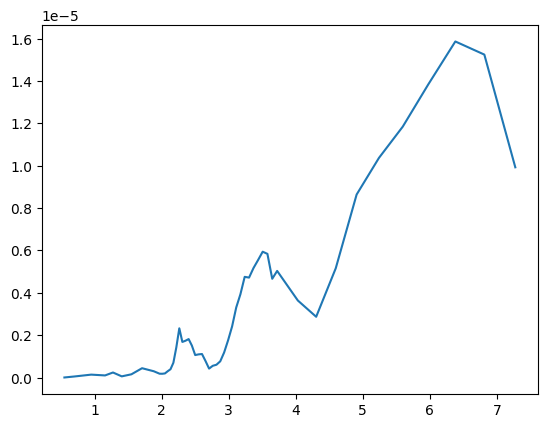

In [6]:
plt.plot(wl, val, label='Binned Model Output')

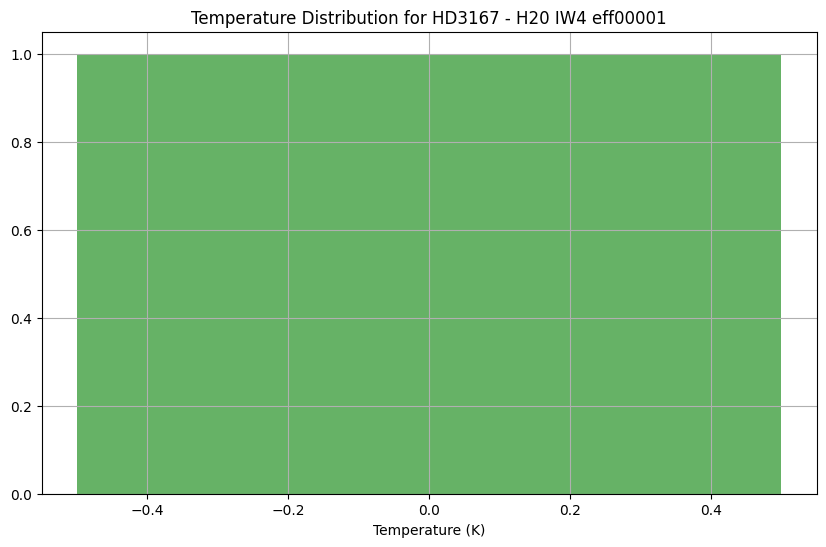

In [14]:
#plot of T distribution
name = "HD3167"
H = '20'
IW = '4'
eff = '00001'

temperature_dist = popt

fig = figure(figsize=(10, 6))
plt.hist(temperature_dist, bins='auto', density=False, alpha=0.6, color='g')
plt.xlabel('Temperature (K)')
plt.ylabel('')
plt.title(f'Temperature Distribution for {name} - H{H} IW{IW} eff{eff}')
plt.grid()
plt.show()